# Tutorial 03 — MLPs & Backprop
## Topic 3.1: Limitations of Perceptrons (linear separability, XOR)

A **perceptron** is an (affine) **linear classifier**: it computes a linear filter  
\[
h(x)=w^\top x + b
\]
and then applies a nonlinearity \(f(h)\) (step, sigmoid, tanh, …).  
Crucial point: **the decision boundary is still a hyperplane** \(w^\top x + b=0\).  
So: perceptrons can only solve problems that are **linearly separable**.

Classic Boolean examples in \(\mathbb{R}^2\):
- **AND** and **OR** are linearly separable (a single line works).
- **XOR** is **not** linearly separable (no single line can separate the classes).

But XOR *is* solvable by **multiple perceptrons** (a tiny MLP):  
\[
\text{XOR}(x_1,x_2) = (x_1 \wedge \neg x_2)\ \vee\ (\neg x_1 \wedge x_2)
\]
This is “divide & conquer” with two hidden units + one output unit.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def step(z):
    return (z >= 0).astype(int)

def perceptron_predict(X, w, b):
    # X: (n,2), w: (2,)
    return step(X @ w + b)

def plot_points_and_boundary(X, y, w=None, b=None, title=""):
    plt.figure()
    # points
    plt.scatter(X[y==0,0], X[y==0,1], marker="o", label="y=0")
    plt.scatter(X[y==1,0], X[y==1,1], marker="x", label="y=1")
    # boundary line: w1 x1 + w2 x2 + b = 0
    if w is not None:
        xs = np.linspace(-0.5, 1.5, 200)
        if abs(w[1]) > 1e-12:
            ys = -(w[0]*xs + b)/w[1]
            plt.plot(xs, ys)
        else:
            # vertical line
            x0 = -b/w[0]
            plt.axvline(x0)
    plt.xlim(-0.5, 1.5); plt.ylim(-0.5, 1.5)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, alpha=0.3)
    plt.title(title)
    plt.legend()
    plt.show()


In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y_and = np.array([0,0,0,1])
y_or  = np.array([0,1,1,1])
y_xor = np.array([0,1,1,0])


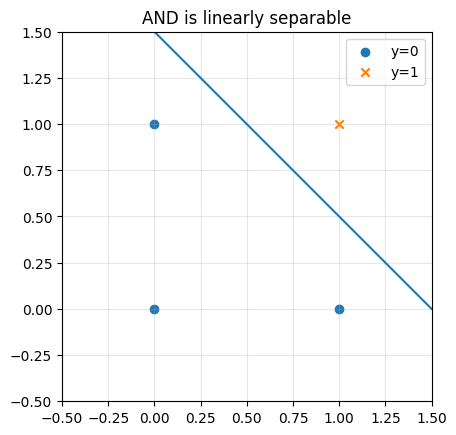

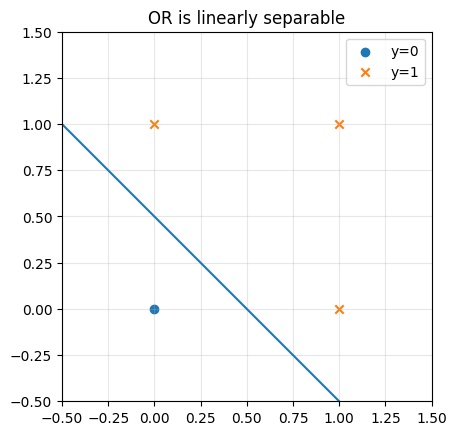

AND predictions: [0 0 0 1]
OR predictions : [0 1 1 1]


In [3]:
# Hand-picked weights (classic):
# AND: w=[1,1], b=-1.5
w_and = np.array([1.0, 1.0]); b_and = -1.5
plot_points_and_boundary(X, y_and, w_and, b_and, "AND is linearly separable")

# OR: w=[1,1], b=-0.5
w_or = np.array([1.0, 1.0]); b_or = -0.5
plot_points_and_boundary(X, y_or, w_or, b_or, "OR is linearly separable")

print("AND predictions:", perceptron_predict(X, w_and, b_and))
print("OR predictions :", perceptron_predict(X, w_or,  b_or))


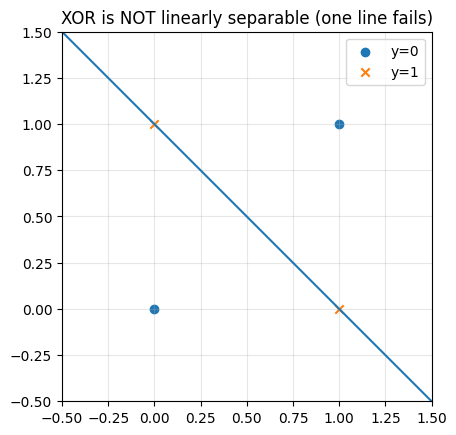

XOR true: [0 1 1 0]
XOR pred: [0 1 1 1]


In [4]:
# Try a "reasonable" linear boundary anyway (won't work)
w_try = np.array([1.0, 1.0]); b_try = -1.0
plot_points_and_boundary(X, y_xor, w_try, b_try, "XOR is NOT linearly separable (one line fails)")

print("XOR true:", y_xor)
print("XOR pred:", perceptron_predict(X, w_try, b_try))


### Why XOR fails (geometric intuition)
For XOR, the positive class sits on two opposite corners of the square.
Any single hyperplane splits the plane into **one connected half-space** vs the other.
But XOR needs **two disjoint positive regions** → impossible with one line.


In [5]:
# Hidden units:
# h1 = AND(x1, not x2)  -> w=[ 1,-1], b=-0.5
# h2 = AND(not x1, x2)  -> w=[-1, 1], b=-0.5
w_h1, b_h1 = np.array([ 1.0,-1.0]), -0.5
w_h2, b_h2 = np.array([-1.0, 1.0]), -0.5

h1 = perceptron_predict(X, w_h1, b_h1)
h2 = perceptron_predict(X, w_h2, b_h2)

H = np.vstack([h1, h2]).T  # shape (4,2)

# Output unit: OR(h1,h2) -> w=[1,1], b=-0.5
w_out, b_out = np.array([1.0, 1.0]), -0.5
y_hat = perceptron_predict(H.astype(float), w_out, b_out)

print("h1:", h1, " (x1 AND not x2)")
print("h2:", h2, " (not x1 AND x2)")
print("XOR true:", y_xor)
print("XOR via 2-layer perceptrons:", y_hat)


h1: [0 0 1 0]  (x1 AND not x2)
h2: [0 1 0 0]  (not x1 AND x2)
XOR true: [0 1 1 0]
XOR via 2-layer perceptrons: [0 1 1 0]


### Takeaways (high-yield)
- A perceptron is a **linear separator** in input space (hyperplane).
- **Nonlinearity ≠ nonlinear decision boundary** for a *single* perceptron.
- XOR is the canonical counterexample: **not linearly separable**.
- Two-layer structure (hidden layer) lets you “stitch” multiple half-spaces → **MLP**.


# Tutorial 03 — Topic 3.1 (SymPy walkthrough)
## Limitations of a single Perceptron (linear separability) + XOR

Perceptron forward pass (matrix form):

Given inputs \(X\in\mathbb{R}^{N\times d}\), weights \(w\in\mathbb{R}^{d\times 1}\), bias \(b\in\mathbb{R}\)

$$
z = Xw + b\mathbf{1}
\quad,\quad
\hat y = \mathrm{step}(z)
$$

We use the convention **step(z) = 1 if z ≥ 0, else 0**.
In SymPy we represent step with **Heaviside(z, 1)** (value at 0 is 1).


In [6]:
import sympy as sp
from IPython.display import display, Markdown

sp.init_printing(use_unicode=True)

def show(name, obj):
    display(Markdown(f"**{name}**"))
    display(obj)


**X (4×2)**

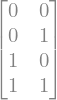

**y_AND**

**y_OR**

**y_XOR**

In [7]:
# Inputs: all 2-bit patterns
X = sp.Matrix([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Labels (column vectors)
y_AND = sp.Matrix([0, 0, 0, 1])
y_OR  = sp.Matrix([0, 1, 1, 1])
y_XOR = sp.Matrix([0, 1, 1, 0])

show("X (4×2)", X)
show("y_AND", y_AND)
show("y_OR",  y_OR)
show("y_XOR", y_XOR)


In [8]:
# step(z) = 1 if z >= 0 else 0
step = lambda z: sp.Heaviside(z, 1)

def perceptron_forward(X, w, b):
    """
    X: (N×d) Matrix
    w: (d×1) Matrix
    b: scalar
    returns: z (N×1), yhat (N×1)
    """
    ones = sp.ones(X.rows, 1)
    z = X*w + b*ones
    yhat = z.applyfunc(step)
    return z, yhat


**w (symbolic)**

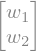

**z = Xw + b·1  (symbolic)**

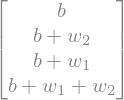

**ŷ = step(z)   (symbolic)**

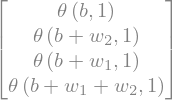

In [9]:
w1, w2, b = sp.symbols("w1 w2 b", real=True)
w = sp.Matrix([w1, w2])

z_sym, yhat_sym = perceptron_forward(X, w, b)

show("w (symbolic)", w)
show("z = Xw + b·1  (symbolic)", z_sym)
show("ŷ = step(z)   (symbolic)", yhat_sym)


**w_AND**

**b_AND**

**z_AND = Xw + b·1**

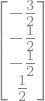

**ŷ_AND = step(z_AND)**

**y_AND (true)**

**ŷ_AND == y_AND ?**

In [10]:
w_AND = sp.Matrix([1, 1])
b_AND = sp.Rational(-3, 2)   # -1.5

z_AND, yhat_AND = perceptron_forward(X, w_AND, b_AND)

show("w_AND", w_AND)
show("b_AND", b_AND)
show("z_AND = Xw + b·1", z_AND)
show("ŷ_AND = step(z_AND)", yhat_AND)
show("y_AND (true)", y_AND)
show("ŷ_AND == y_AND ?", sp.Eq(yhat_AND, y_AND))


**w_OR**

**b_OR**

**z_OR = Xw + b·1**

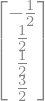

**ŷ_OR = step(z_OR)**

**y_OR (true)**

**ŷ_OR == y_OR ?**

In [11]:
w_OR = sp.Matrix([1, 1])
b_OR = sp.Rational(-1, 2)    # -0.5

z_OR, yhat_OR = perceptron_forward(X, w_OR, b_OR)

show("w_OR", w_OR)
show("b_OR", b_OR)
show("z_OR = Xw + b·1", z_OR)
show("ŷ_OR = step(z_OR)", yhat_OR)
show("y_OR (true)", y_OR)
show("ŷ_OR == y_OR ?", sp.Eq(yhat_OR, y_OR))


## XOR: why a single perceptron is impossible (inequality proof)

For XOR we want:
- (0,0) → 0  ⇒  b < 0
- (1,0) → 1  ⇒  w1 + b ≥ 0
- (0,1) → 1  ⇒  w2 + b ≥ 0
- (1,1) → 0  ⇒  w1 + w2 + b < 0

Add the two "≥ 0" constraints:
(w1 + b) + (w2 + b) ≥ 0  ⇒  w1 + w2 + 2b ≥ 0

But if b < 0, then −b > 0, so:
w1 + w2 + b = (w1 + w2 + 2b) − b  ≥  0 − b  =  −b  > 0

So we deduce:  w1 + w2 + b > 0
Contradiction to the required: w1 + w2 + b < 0

Hence: **XOR is not linearly separable → one perceptron cannot represent it.**


**W1 (input→hidden)**

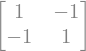

**b1_row (hidden biases)**

**Z1 = X·W1 + 1·b1_row**

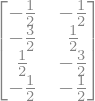

**H = step(Z1)**

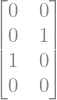

**w2 (hidden→out)**

**b2 (out bias)**

**Z2 = H·w2 + b2·1**

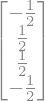

**ŷ_XOR = step(Z2)**

**y_XOR (true)**

**ŷ_XOR == y_XOR ?**

In [12]:
# Hidden layer (2 units):
# h1 = step( x1 - x2 - 0.5 )  -> fires only for (1,0)
# h2 = step(-x1 + x2 - 0.5 )  -> fires only for (0,1)

W1 = sp.Matrix([
    [ 1, -1],
    [-1,  1]
])  # (2×2)

b1_row = sp.Matrix([[-sp.Rational(1,2), -sp.Rational(1,2)]])  # (1×2), broadcast down rows

Z1 = X*W1 + sp.ones(X.rows, 1)*b1_row    # (4×2)
H  = Z1.applyfunc(step)                 # (4×2)

show("W1 (input→hidden)", W1)
show("b1_row (hidden biases)", b1_row)
show("Z1 = X·W1 + 1·b1_row", Z1)
show("H = step(Z1)", H)

# Output layer: OR over the two hidden bits
w2 = sp.Matrix([1, 1])             # (2×1)
b2 = -sp.Rational(1,2)

Z2 = H*w2 + b2*sp.ones(X.rows, 1)  # (4×1)
yhat_XOR = Z2.applyfunc(step)

show("w2 (hidden→out)", w2)
show("b2 (out bias)", b2)
show("Z2 = H·w2 + b2·1", Z2)
show("ŷ_XOR = step(Z2)", yhat_XOR)
show("y_XOR (true)", y_XOR)
show("ŷ_XOR == y_XOR ?", sp.Eq(yhat_XOR, y_XOR))


In [13]:
clear

# Tutorial 03 — Topic 3.2: Feedforward MLP (with indices + matrices)

A **feedforward MLP** is a directed acyclic graph (DAG): signals only flow from earlier layers to deeper layers.

Notation (per layer $v$):
- $s^v_j$: **activity/output** of neuron $j$ in layer $v$
- $h^v_j$: **total input** (pre-activation) of neuron $j$ in layer $v$
- $s^v_j = f^v_j(h^v_j)$, where $f^v_j$ is the activation function (identity, sigmoid, tanh, ...)

Layer indices:
- $v = 0$ is the input layer (it holds the observations $x$)
- $v = L$ is the output layer
- layers in between are hidden layers

Weights (index reading):
- $w^{v'v}_{ij}$ connects **from** neuron $(v, j)$ **to** neuron $(v', i)$ (1 hop).
- Bias can be written as a special parent neuron with fixed activity $s^v_0 = 1$.
  Then bias weights are simply the $j=0$ entries, e.g. $w^{v'v}_{i0}$.

For a fully connected layer transition $v \to v'$:
- stack activities into a vector (including bias):
  $$s^v = (s^v_0, s^v_1, ..., s^v_{N_v})^\top,\quad s^v_0 = 1$$
- build a weight matrix $W^{v'v} \in \mathbb{R}^{(N_v+1)\times N_{v'}}$ where each column is the weight-vector into one neuron in layer $v'$.
- then the vectorized pre-activation is:
  $$h^{v'} = (W^{v'v})^\top \, s^v$$
- and activations are:
  $$s^{v'} = f^{v'}(h^{v'}) \quad \text{(applied elementwise)}$$


In [20]:
import sympy as sp
from IPython.display import display, Markdown

sp.init_printing(use_unicode=True)

def show(name, obj):
    display(Markdown(f"**{name}**"))
    display(obj)

sigmoid = lambda z: 1/(1 + sp.exp(-z))


## Step 1: Define one concrete MLP (small, but fully symbolic)

We will build a tiny network:

- Input layer $v=0$ with $N_0 = 2$ observed features $x_1, x_2$
- Hidden layer $v'=1$ with $N_1 = 3$ neurons
- Output layer $v''=2$ with $N_2 = 1$ neuron

We will explicitly construct:
- $s^0$ (input activities incl. bias)
- $W^{10}$ (input→hidden weights)
- $h^1 = (W^{10})^\top s^0$
- $s^1 = \sigma(h^1)$
- augment hidden with bias to get $s^1_{\text{aug}}$
- $W^{21}$ (hidden→output weights)
- $h^2 = (W^{21})^\top s^1_{\text{aug}}$
- $y = \sigma(h^2)$


**s^0 (input activities incl. bias)**

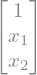

In [21]:
x1, x2 = sp.symbols("x1 x2", real=True)

# s^0 = (1, x1, x2)^T
s0 = sp.Matrix([1, x1, x2])

show("s^0 (input activities incl. bias)", s0)


**W^{10} (input→hidden), columns are weight-vectors into each hidden neuron**

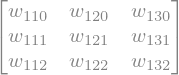

**(W^{10})^T**

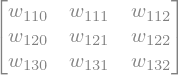

In [22]:
# Hidden layer has N1 = 3 neurons, so W^{10} shape is (N0+1)×N1 = 3×3.
w110, w111, w112 = sp.symbols("w110 w111 w112", real=True)  # into hidden neuron i=1 from j=0,1,2
w120, w121, w122 = sp.symbols("w120 w121 w122", real=True)  # into hidden neuron i=2
w130, w131, w132 = sp.symbols("w130 w131 w132", real=True)  # into hidden neuron i=3

# weight vectors (columns)
w1 = sp.Matrix([w110, w111, w112])
w2 = sp.Matrix([w120, w121, w122])
w3 = sp.Matrix([w130, w131, w132])

W10 = sp.Matrix.hstack(w1, w2, w3)  # (3×3)

show("W^{10} (input→hidden), columns are weight-vectors into each hidden neuron", W10)
show("(W^{10})^T", W10.T)


**h^1 = (W^{10})^T s^0**

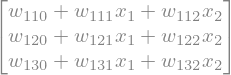

**Scalar check: h^1_2 = w2 · s^0 = Σ_{j=0..2} w^{10}_{2j} s^0_j**

In [23]:
h1 = W10.T * s0
show("h^1 = (W^{10})^T s^0", h1)

# Scalar expansion for one neuron, e.g. hidden neuron i=2
h1_i2 = sp.simplify(w2.dot(s0))  # dot product column w2 with s0
show("Scalar check: h^1_2 = w2 · s^0 = Σ_{j=0..2} w^{10}_{2j} s^0_j", h1_i2)


**s^1 = σ(h^1)  (elementwise)**

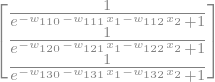

In [24]:
s1 = h1.applyfunc(sigmoid)
show("s^1 = σ(h^1)  (elementwise)", s1)


**s^1_aug (hidden activities incl. bias)**

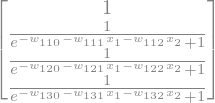

**W^{21} (hidden→output), single column**

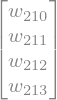

**(W^{21})^T**

**h^2 = (W^{21})^T s^1_aug**

**y = σ(h^2)**

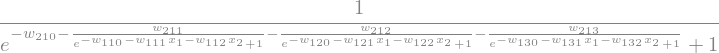

In [25]:
# Augment hidden activities with bias: s^1_aug = (1, s^1_1, s^1_2, s^1_3)^T
s1_aug = sp.Matrix([1, s1[0], s1[1], s1[2]])
show("s^1_aug (hidden activities incl. bias)", s1_aug)

# Output layer has N2 = 1 neuron, so W^{21} shape is (N1+1)×N2 = 4×1
w210, w211, w212, w213 = sp.symbols("w210 w211 w212 w213", real=True)
W21 = sp.Matrix([w210, w211, w212, w213])  # a single column

show("W^{21} (hidden→output), single column", W21)
show("(W^{21})^T", W21.T)

h2 = W21.T * s1_aug
show("h^2 = (W^{21})^T s^1_aug", h2)

y = sigmoid(h2[0])
show("y = σ(h^2)", y)


## What you just saw (index navigation made concrete)

- $W^{10}$ has shape $(N_0+1)\times N_1 = 3\times 3$.
  - rows correspond to **source indices** $j=0,1,2$ (bias, $x_1$, $x_2$)
  - columns correspond to **destination indices** $i=1,2,3$ (hidden neurons)
  - entry in row $j$, col $i$ is the weight $w^{10}_{ij}$ (dest-first indexing)

- The vector formula
  $$h^{1} = (W^{10})^\top s^0$$
  is exactly the scalar formula for each neuron:
  $$h^1_i = \sum_{j=0}^{N_0} w^{10}_{ij}\, s^0_j$$

Same pattern repeats from hidden to output:
$$h^{2} = (W^{21})^\top s^1_{\text{aug}}$$


**Numeric s^0**

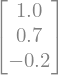

**Numeric W^{10}**

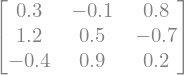

**Numeric h^1**

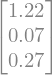

**Numeric s^1**

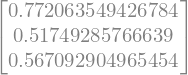

**Numeric s^1_aug**

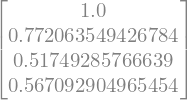

**Numeric W^{21}**

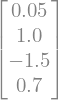

**Numeric h^2**

**Numeric y**

In [26]:
# Example numeric substitution (feel free to change)
subs = {
    x1: 0.7, x2: -0.2,

    w110: 0.3,  w111: 1.2,  w112: -0.4,
    w120: -0.1, w121: 0.5,  w122: 0.9,
    w130: 0.8,  w131: -0.7, w132: 0.2,

    w210: 0.05, w211: 1.0, w212: -1.5, w213: 0.7
}

show("Numeric s^0", sp.N(s0.subs(subs)))
show("Numeric W^{10}", sp.N(W10.subs(subs)))
show("Numeric h^1", sp.N(h1.subs(subs)))
show("Numeric s^1", sp.N(s1.subs(subs)))
show("Numeric s^1_aug", sp.N(s1_aug.subs(subs)))
show("Numeric W^{21}", sp.N(W21.subs(subs)))
show("Numeric h^2", sp.N(h2.subs(subs)))
show("Numeric y", sp.N(y.subs(subs)))


# Topic 3.3 — MLPs are universal function approximators

Idea: a (shallow) MLP with **one hidden layer** can approximate (almost) any “nice” target function.

We want to approximate a target mapping
$$y_T: x \mapsto y_T(x)$$
with an MLP
$$y(x; w)=\sum_{i=1}^{M} w^{21}_i \, f\!\left(\sum_{j=1}^{N} w^{10}_{ij} x_j - \theta_i\right).$$

Universal approximation (Funahashi 1989, also Hornik et al. 1989):
If $y_T(x)$ is continuous on a **compact** set $K$ and $f$ is non-constant, bounded, monotonically increasing, continuous,
then for every $\varepsilon>0$ there exist parameters such that
$$\max_{x\in K} |y_T(x)-y(x;w)| \le \varepsilon.$$

Translation into human:
- **width** (number of hidden units $M$) gives expressivity
- it’s an **existence theorem** (doesn’t hand you the weights; it says they *exist*)


clear

In [28]:
import sympy as sp
from IPython.display import display, Markdown

sp.init_printing(use_unicode=True)

def show(name, obj):
    display(Markdown(f"**{name}**"))
    display(obj)

x = sp.Symbol("x", real=True)
M = sp.Symbol("M", integer=True, positive=True)

# Activation f(z): keep it abstract first (we’ll later pick sigmoid)
f = sp.Function("f")

# Parameters as indexed symbols
a = sp.IndexedBase("a")      # a[i] corresponds to w_i^{21}
b = sp.IndexedBase("b")      # b[i] corresponds to w_{i1}^{10} for 1D input
theta = sp.IndexedBase("θ")  # theta[i]

i = sp.Idx("i", M)

y_expr = sp.summation(a[i] * f(b[i]*x - theta[i]), (i, 1, M-1))

show("Symbolic MLP (1D input, 1 hidden layer):  y(x)=Σ a_i f(b_i x - θ_i)", y_expr)


**Symbolic MLP (1D input, 1 hidden layer):  y(x)=Σ a_i f(b_i x - θ_i)**

M - 1                      
 ___                       
 ╲                         
  ╲                        
  ╱   f(x⋅b[i] - θ[i])⋅a[i]
 ╱                         
 ‾‾‾                       
i = 1                      

## A constructive demo (not the theorem): “fixed hidden units + linear solve”

We’ll pick a concrete target on a compact interval $K=[0,1]$, e.g.
$$y_T(x)=\sin(2\pi x).$$

We choose:
- hidden units: $\phi_i(x)=\sigma(k(x-c_i))$ with fixed slope $k$ and centers $c_i$
- output: $y(x)=\sum_i a_i \phi_i(x)$

Now only the output weights $a_i$ are unknown → this becomes **linear least squares**.

Let training samples be $(x^{(\alpha)}, y_T^{(\alpha)})$, $\alpha=1..p$.

Define the design matrix
$$\Phi_{\alpha i}=\phi_i\!\left(x^{(\alpha)}\right).$$

Then the least squares solution is
$$a = (\Phi^\top \Phi)^{-1}\Phi^\top y_T.$$

This is a “show the mechanism” construction: it illustrates approximation via sums of squashed step-like units.


**Φ (design matrix) shape = p×M**

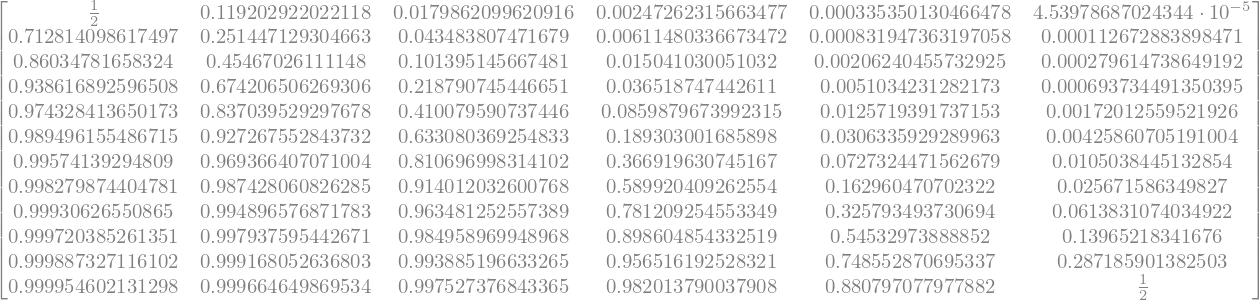

**y_T (targets) shape = p×1**

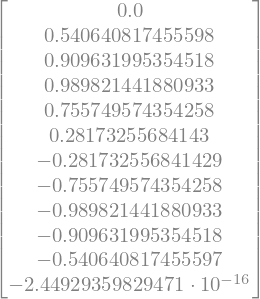

**ΦᵀΦ shape = M×M**

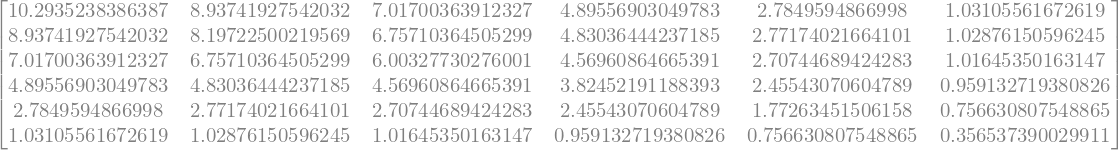

**Φᵀ y_T shape = M×1**

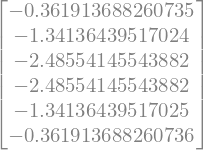

**â (output weights) shape = M×1**

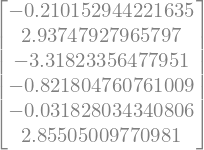

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Hyperparameters ---
p = 12          # number of training points
M_num = 6       # number of hidden units
k = 10.0        # sigmoid slope ("sharpness")

# Training points on K=[0,1]
x_train = np.linspace(0, 1, p)
y_train = np.sin(2*np.pi*x_train)

# Hidden centers (fixed)
centers = np.linspace(0, 1, M_num)

# SymPy objects
sigma = lambda z: 1/(1 + sp.exp(-z))

# Build Φ (p×M) in SymPy, but filled numerically (so we can print matrices cleanly)
Phi = sp.Matrix([
    [sigma(k*(float(xa) - float(ci))) for ci in centers]
    for xa in x_train
])

yT = sp.Matrix([float(v) for v in y_train])  # (p×1)

show("Φ (design matrix) shape = p×M", Phi)
show("y_T (targets) shape = p×1", yT)

# Normal equations components
PhiT_Phi = Phi.T * Phi
PhiT_y   = Phi.T * yT

show("ΦᵀΦ shape = M×M", PhiT_Phi)
show("Φᵀ y_T shape = M×1", PhiT_y)

# Solve for a: (ΦᵀΦ) a = Φᵀ y
a_hat = PhiT_Phi.LUsolve(PhiT_y)

show("â (output weights) shape = M×1", a_hat)


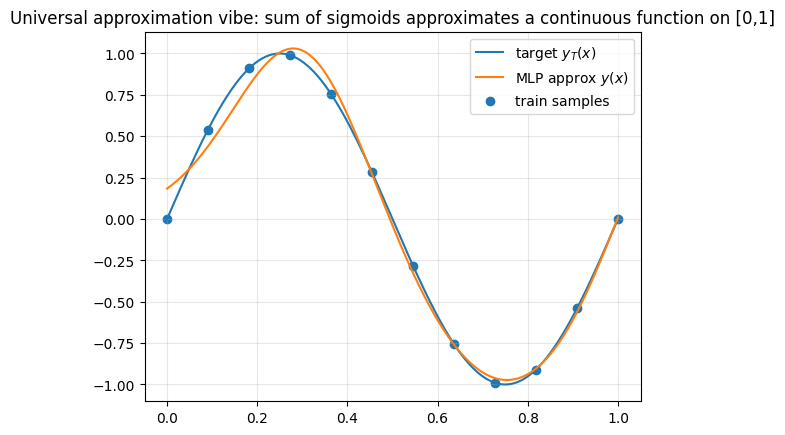

max |y_T - y| on grid ≈ 0.18348412197676908


In [30]:
def y_hat_numeric(x_vals):
    # compute y(x)=Σ a_i σ(k(x-c_i))
    y_out = []
    for xv in x_vals:
        phi = np.array([1/(1+np.exp(-k*(xv-ci))) for ci in centers], dtype=float)  # (M,)
        y_out.append(float(np.dot(phi, np.array(a_hat, dtype=float).reshape(-1))))
    return np.array(y_out)

x_grid = np.linspace(0, 1, 400)
y_grid_true = np.sin(2*np.pi*x_grid)
y_grid_pred = y_hat_numeric(x_grid)

plt.figure()
plt.plot(x_grid, y_grid_true, label="target $y_T(x)$")
plt.plot(x_grid, y_grid_pred, label="MLP approx $y(x)$")
plt.scatter(x_train, y_train, label="train samples")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Universal approximation vibe: sum of sigmoids approximates a continuous function on [0,1]")
plt.show()

# Sup-norm-ish error on the grid (proxy for max_{x∈K})
err_inf = np.max(np.abs(y_grid_true - y_grid_pred))
print("max |y_T - y| on grid ≈", err_inf)


## What 3.3 actually teaches (beyond “terms”)

- This is the **expressivity claim**: width $M$ can buy you approximation power.
- It’s about approximation on **compact** domains $K$ (closed + bounded).
- The theorem is existential: it guarantees there exists some $w$ such that the uniform error can be made $<\varepsilon$.
- It sets up the next chapter: if the solution exists, then training is “just” the optimization problem of finding it.


# Topic 3.4 — Training a neural network (gradient-based learning)

Goal: choose parameters $w$ to minimize the **training error**
$$E_T(w)=\frac{1}{p}\sum_{\alpha=1}^{p} e\!\left(y_T^{(\alpha)},\,y(x^{(\alpha)};w)\right).$$

Gradient descent update (iterative minimization):
$$w(t+1)=w(t)-\eta\,\nabla_w E_T(w(t)).$$

For a single output and quadratic error
$$e(y_T,y)=\frac{1}{2}(y_T-y)^2,$$
the chain rule decomposes the gradient into a **cost-term** and a **model-term**:
$$\frac{\partial e}{\partial w}=\frac{\partial e}{\partial y}\cdot\frac{\partial y}{\partial w}.$$

For a single connectionist neuron
$$y=f(h),\quad h=\sum_{j=0}^{N} w_j x_j,$$
you get
$$\frac{\partial e}{\partial w_j}=(y-y_T)\,f'(h)\,x_j.$$


In [31]:
clear

In [32]:
import sympy as sp
from IPython.display import display, Markdown

sp.init_printing(use_unicode=True)

def show(name, obj):
    display(Markdown(f"**{name}**"))
    display(obj)


## Step-by-step with matrices (vectorized “dataset view”)

We treat the dataset as a matrix:
- $X \in \mathbb{R}^{p\times (N+1)}$  (includes bias column of ones)
- $w \in \mathbb{R}^{(N+1)\times 1}$
- $h = Xw \in \mathbb{R}^{p\times 1}$
- $y = f(h)$ elementwise
- residual $r = y - y_T$

Quadratic training error:
$$E_T(w)=\frac{1}{2p}\|r\|^2=\frac{1}{2p} r^\top r.$$

Gradient for a single neuron model:
$$\nabla_w E_T = \frac{1}{p} X^\top\Big( r \odot f'(h)\Big),$$
where $\odot$ is the Hadamard (elementwise) product.


**X (p×(N+1))**

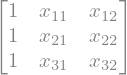

**y_T (p×1)**

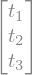

**w ((N+1)×1)**

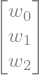

In [33]:
# We'll use p=3 samples, N=2 features + bias -> X is 3×3, w is 3×1.
p = 3

# symbols for data matrix entries (bias column is fixed 1)
x11, x12 = sp.symbols("x11 x12", real=True)
x21, x22 = sp.symbols("x21 x22", real=True)
x31, x32 = sp.symbols("x31 x32", real=True)

X = sp.Matrix([
    [1, x11, x12],
    [1, x21, x22],
    [1, x31, x32],
])

t1, t2, t3 = sp.symbols("t1 t2 t3", real=True)
yT = sp.Matrix([t1, t2, t3])

w0, w1, w2 = sp.symbols("w0 w1 w2", real=True)
w = sp.Matrix([w0, w1, w2])

show("X (p×(N+1))", X)
show("y_T (p×1)", yT)
show("w ((N+1)×1)", w)


**h = X w  (p×1)**

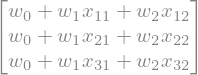

**y = σ(h)  (elementwise) (p×1)**

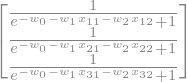

**r = y - y_T  (residual)**

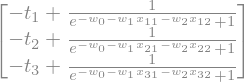

In [34]:
# Pre-activation (net input)
h = X * w
show("h = X w  (p×1)", h)

# Choose an explicit activation for clean derivatives
sigma = lambda z: 1/(1 + sp.exp(-z))

y = h.applyfunc(sigma)
show("y = σ(h)  (elementwise) (p×1)", y)

r = y - yT
show("r = y - y_T  (residual)", r)


**E_T(w) = (1/(2p)) r^T r  (scalar)**

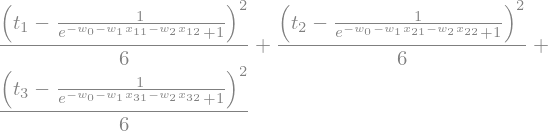

**Cost-term per sample: ∂e/∂y = (y - y_T) = r**

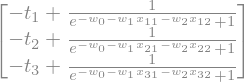

**Model-term per sample: σ'(h) = y ⊙ (1 - y)**

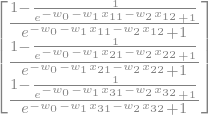

In [35]:
# Training error: E_T = (1/(2p)) * r^T r
E = (r.T * r)[0] / (2*p)
show("E_T(w) = (1/(2p)) r^T r  (scalar)", sp.simplify(E))

# Cost-term: ∂e/∂y for quadratic error is (y - y_T) = r (per sample)
show("Cost-term per sample: ∂e/∂y = (y - y_T) = r", r)

# Model-term: f'(h). For sigmoid: σ'(h) = σ(h)(1-σ(h))
y_prime = y.multiply_elementwise(sp.ones(p,1) - y)
show("Model-term per sample: σ'(h) = y ⊙ (1 - y)", y_prime)


**delta = r ⊙ σ'(h)  (p×1)**

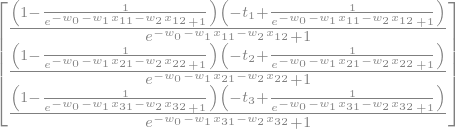

**∇_w E_T = (1/p) X^T delta  ((N+1)×1)**

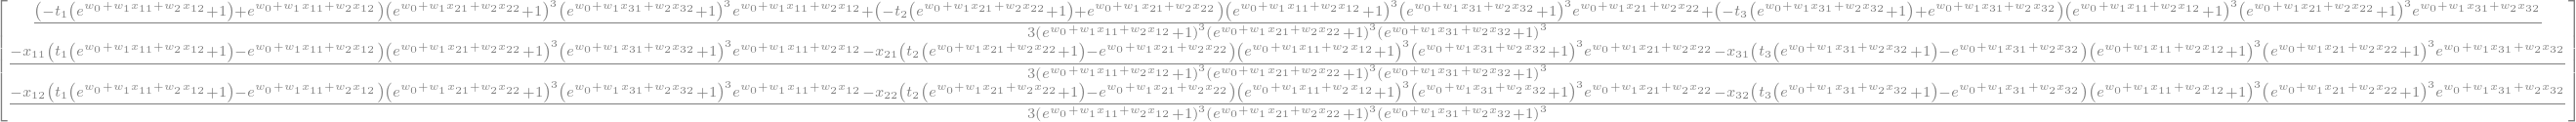

In [36]:
delta = r.multiply_elementwise(y_prime)          # (p×1)
show("delta = r ⊙ σ'(h)  (p×1)", delta)

grad = (X.T * delta) / p                         # ((N+1)×1)
show("∇_w E_T = (1/p) X^T delta  ((N+1)×1)", sp.simplify(grad))


In [37]:
eta = sp.Symbol("η", positive=True, real=True)

w_new = w - eta*grad
show("Gradient descent step: w(t+1) = w(t) - η ∇E_T", sp.simplify(w_new))


**Gradient descent step: w(t+1) = w(t) - η ∇E_T**

⎡             ⎛⎛                1             ⎞ ⎛                 1            ↪
⎢             ⎜⎜1 - ──────────────────────────⎟⋅⎜t₁ - ──────────────────────── ↪
⎢             ⎜⎜     -w₀ - w₁⋅x₁₁ - w₂⋅x₁₂    ⎟ ⎜      -w₀ - w₁⋅x₁₁ - w₂⋅x₁₂   ↪
⎢             ⎜⎝    ℯ                      + 1⎠ ⎝     ℯ                      + ↪
⎢      w₀ + η⋅⎜─────────────────────────────────────────────────────────────── ↪
⎢             ⎜                    ⎛ -w₀ - w₁⋅x₁₁ - w₂⋅x₁₂    ⎞                ↪
⎢             ⎝                  3⋅⎝ℯ                      + 1⎠                ↪
⎢                                                                              ↪
⎢       ⎛    ⎛                1             ⎞ ⎛                 1              ↪
⎢       ⎜x₁₁⋅⎜1 - ──────────────────────────⎟⋅⎜t₁ - ────────────────────────── ↪
⎢       ⎜    ⎜     -w₀ - w₁⋅x₁₁ - w₂⋅x₁₂    ⎟ ⎜      -w₀ - w₁⋅x₁₁ - w₂⋅x₁₂     ↪
⎢       ⎜    ⎝    ℯ                      + 1⎠ ⎝     ℯ                      + 1 ↪
⎢w₁ + η⋅⎜───────────────────

In [ ]:
subs = {
    # data
    x11: 0.0, x12: 0.0,
    x21: 0.0, x22: 1.0,
    x31: 1.0, x32: 0.0,
    t1: 0.0, t2: 1.0, t3: 1.0,

    # weights
    w0: -0.2, w1: 0.8, w2: 0.4,

    eta: 0.5
}

show("Numeric X", sp.N(X.subs(subs)))
show("Numeric y_T", sp.N(yT.subs(subs)))
show("Numeric w", sp.N(w.subs(subs)))

show("Numeric h", sp.N(h.subs(subs)))
show("Numeric y", sp.N(y.subs(subs)))
show("Numeric r", sp.N(r.subs(subs)))
show("Numeric σ'(h)", sp.N(y_prime.subs(subs)))

show("Numeric delta", sp.N(delta.subs(subs)))
show("Numeric grad", sp.N(grad.subs(subs)))
show("Numeric w_new", sp.N(w_new.subs(subs)))


$$\delta_1 = \frac{\partial E}{\partial h_1} = f'(h_1)\,w_2\,\delta_2$$ und dann ist $$\frac{\partial E}{\partial w_1} = \delta_1 \, x,\qquad \frac{\partial E}{\partial w_2} = \delta_2 \, s_1.$$ ### Deine “random vary + check slope” Idee Das ist **finite differences / numerische Gradientenschätzung**. Funktioniert konzeptuell, aber ist bruteforce-teuer: Für $n$ Gewichte brauchst du ~\(2n\) Forward-Passes pro Gradientenschritt: $$\frac{\partial E}{\partial w_k} \approx \frac{E(w_k+\epsilon)-E(w_k-\epsilon)}{2\epsilon}.$$ Backprop braucht dagegen grob: - **1 Forward** + **1 Backward** und liefert alle $\partial E/\partial w_k$ gleichzeitig. Das ist der ganze Zauber: **effiziente Gradientenberechnung** durch Re-use von Zwischenergebnissen (dynamic programming / reverse-mode autodiff). ### Kerngedanke in einem Satz Der Output-Error enthält Info über Hidden-Weights, weil der Output eine **differenzierbare Komposition** dieser Hidden-Weights ist; Backprop ist nur die **Kettenregel** in effizient. Wenn du willst, kann ich 3.4/3.5 als SymPy-Notebook so bauen, dass du wirklich siehst: erst Forward-Graph, dann $\delta$-Vektoren, dann Gradienten für **W¹** und **W²** als Matrizen (ohne Blackbox).

# Topic 3.5 — Backpropagation (MLP gradients via chain rule)

Key idea: the loss $E$ depends on hidden weights because the network output depends on them:
$$E = E(y),\quad y = y(W^{21}, W^{10}, x).$$

Backprop computes gradients efficiently using "error signals" (deltas):
- output delta: $\delta^{(2)} = \frac{\partial E}{\partial h^{(2)}}$
- hidden delta: $\delta^{(1)} = \frac{\partial E}{\partial h^{(1)}}$

Then gradients are simple outer products (with bias-augmented activities).


In [38]:
clear


In [39]:
import sympy as sp
from IPython.display import display, Markdown

sp.init_printing(use_unicode=True)

def show(name, obj):
    display(Markdown(f"**{name}**"))
    display(obj)


## Network we differentiate (tiny but complete)

We use a 2-layer MLP (1 hidden layer), **with bias via augmentation**:

- Input has $N_0=2$ features, augmented to $s^0_{\text{aug}}=(1,x_1,x_2)^\top$  (shape $3\times 1$)
- Hidden has $N_1=2$ neurons:
  $$h^{(1)} = (W^{10})^\top s^0_{\text{aug}} \quad (2\times 1)$$
  $$s^{(1)} = f(h^{(1)}) \quad (2\times 1)$$
  Augment: $s^{(1)}_{\text{aug}}=(1,s^{(1)}_1,s^{(1)}_2)^\top$ (shape $3\times 1$)
- Output has $N_2=1$ neuron:
  $$h^{(2)} = (W^{21})^\top s^{(1)}_{\text{aug}} \quad (1\times 1)$$
  $$y = g(h^{(2)})$$

Loss per sample (quadratic):
$$E=\frac12(y-t)^2$$


**s^0_aug = (1, x1, x2)^T**

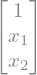

**W^{10} (3×2)**

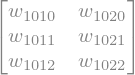

**(W^{10})^T (2×3)**

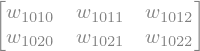

**W^{21} (3×1)**

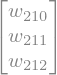

**(W^{21})^T (1×3)**

In [40]:
# input + target
x1, x2, t = sp.symbols("x1 x2 t", real=True)

# activations
f = lambda z: 1/(1 + sp.exp(-z))   # sigmoid for hidden
g = lambda z: 1/(1 + sp.exp(-z))   # sigmoid for output

# augmented input activity s0_aug (3×1)
s0_aug = sp.Matrix([1, x1, x2])
show("s^0_aug = (1, x1, x2)^T", s0_aug)

# W10: (N0+1)×N1 = 3×2
w10_10, w10_11, w10_12 = sp.symbols("w10_10 w10_11 w10_12", real=True)  # into hidden neuron 1 from j=0,1,2
w10_20, w10_21, w10_22 = sp.symbols("w10_20 w10_21 w10_22", real=True)  # into hidden neuron 2

W10 = sp.Matrix([
    [w10_10, w10_20],
    [w10_11, w10_21],
    [w10_12, w10_22],
])
show("W^{10} (3×2)", W10)
show("(W^{10})^T (2×3)", W10.T)

# W21: (N1+1)×N2 = 3×1
w21_0, w21_1, w21_2 = sp.symbols("w21_0 w21_1 w21_2", real=True)
W21 = sp.Matrix([w21_0, w21_1, w21_2])
show("W^{21} (3×1)", W21)
show("(W^{21})^T (1×3)", W21.T)


**h^(1) = (W10)^T s0_aug  (2×1)**

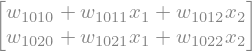

**s^(1) = f(h^(1))        (2×1)**

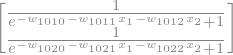

**s^(1)_aug = (1, s1_1, s1_2)^T (3×1)**

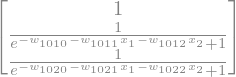

**h^(2) = (W21)^T s1_aug  (1×1)**

**y = g(h^(2))             (scalar)**

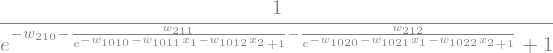

**E = 1/2 (y - t)^2**

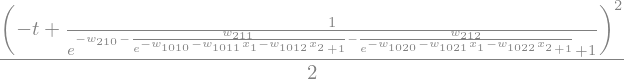

In [41]:
# hidden pre-activation and activation
h1 = W10.T * s0_aug               # (2×1)
s1 = h1.applyfunc(f)              # (2×1)

s1_aug = sp.Matrix([1, s1[0], s1[1]])  # (3×1)

# output
h2 = (W21.T * s1_aug)             # (1×1)
y  = g(h2[0])                     # scalar

show("h^(1) = (W10)^T s0_aug  (2×1)", h1)
show("s^(1) = f(h^(1))        (2×1)", s1)
show("s^(1)_aug = (1, s1_1, s1_2)^T (3×1)", s1_aug)
show("h^(2) = (W21)^T s1_aug  (1×1)", h2)
show("y = g(h^(2))             (scalar)", y)

# loss
E = sp.Rational(1,2) * (y - t)**2
show("E = 1/2 (y - t)^2", E)


## Backprop deltas (the whole secret)

Define deltas as derivatives w.r.t. pre-activations:

Output delta:
$$\delta^{(2)} = \frac{\partial E}{\partial h^{(2)}} 
= \frac{\partial E}{\partial y}\frac{\partial y}{\partial h^{(2)}}.$$

Hidden delta (vector):
$$\delta^{(1)} = \frac{\partial E}{\partial h^{(1)}} 
= \left(\frac{\partial h^{(2)}}{\partial s^{(1)}}\right)^\top \delta^{(2)} \odot f'(h^{(1)}).$$

Because bias has no parent, we use only the **non-bias** output weights:
If $W^{21} = (w_{0}, w_{1}, w_{2})^\top$ then
$$W^{21}_{\text{no-bias}} = (w_1, w_2)^\top.$$


**dE/dy = (y - t)**

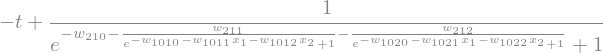

**dy/dh2 = g'(h2) = y(1-y)**

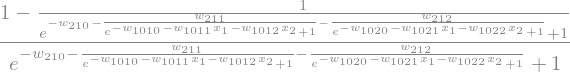

**δ^(2) = dE/dh2**

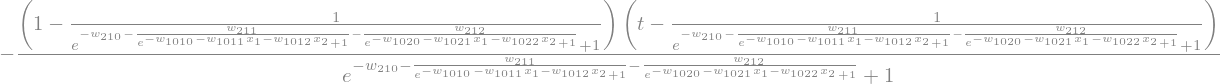

**W21_no_bias = (w21_1, w21_2)^T (2×1)**

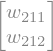

**f'(h1) = s1 ⊙ (1 - s1) (2×1)**

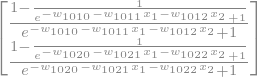

**δ^(1) = (W21_no_bias δ2) ⊙ f'(h1)  (2×1)**

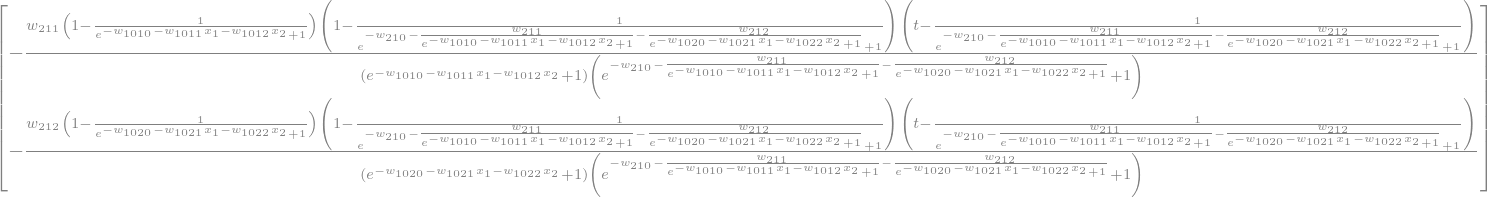

In [42]:
# derivatives of activations
def sigmoid_prime(sig):
    return sig * (1 - sig)   # if sig = sigmoid(z)

# output delta δ2 (scalar)
dE_dy = (y - t)
dy_dh2 = sigmoid_prime(y)
delta2 = sp.simplify(dE_dy * dy_dh2)   # scalar

show("dE/dy = (y - t)", dE_dy)
show("dy/dh2 = g'(h2) = y(1-y)", dy_dh2)
show("δ^(2) = dE/dh2", delta2)

# hidden delta δ1 (2×1)
# h2 = w21_0*1 + w21_1*s1_1 + w21_2*s1_2
W21_no_bias = sp.Matrix([w21_1, w21_2])      # (2×1)

fprime_h1 = s1.applyfunc(sigmoid_prime)      # (2×1), since s1 already = sigmoid(h1)
delta1 = sp.simplify( W21_no_bias * delta2 ).multiply_elementwise(fprime_h1)

show("W21_no_bias = (w21_1, w21_2)^T (2×1)", W21_no_bias)
show("f'(h1) = s1 ⊙ (1 - s1) (2×1)", fprime_h1)
show("δ^(1) = (W21_no_bias δ2) ⊙ f'(h1)  (2×1)", delta1)


## Gradients as outer products

For one sample:

- Output weights:
$$\frac{\partial E}{\partial W^{21}} = s^{(1)}_{\text{aug}} \, \delta^{(2)}$$
(shape $3\times 1$)

- Hidden weights:
$$\frac{\partial E}{\partial W^{10}} = s^{0}_{\text{aug}} \, (\delta^{(1)})^\top$$
(shape $3\times 2$)

This is why backprop is fast:
- compute deltas once,
- then gradients are just matrix products / outer products.


# Topic 3.6 — Symmetries

Because MLPs are layered, the parameter space has **symmetries**:
there exist different weight sets $w$ and $w'$ such that
$$y(x;w)=y(x;w').$$

Two key symmetries (for a hidden layer with $N$ neurons):

1) Permutation (relabel hidden neurons):
- permute columns of $W^{10}$
- permute the corresponding (non-bias) entries of $W^{21}$
Result: same network function.

2) Sign-reversal across layers (needs an odd activation like $\tanh$):
- flip sign of weights *into* a hidden neuron
- flip sign of weights *out of* that neuron
Result: same network function.


**s^0 = (1, x1, x2)^T**

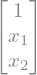

**W^{10} (3×2)**

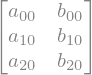

**W^{21} (3×1)**

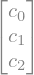

**h^(1) = (W10)^T s0**

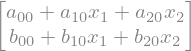

**s^(1) = f(h^(1))**

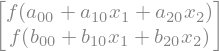

**s^(1)_aug = (1, s1_1, s1_2)^T**

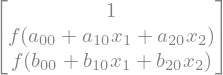

**y = (W21)^T s1_aug**

In [45]:
# Inputs
x1, x2 = sp.symbols("x1 x2", real=True)
s0 = sp.Matrix([1, x1, x2])     # s^0_aug (3×1)

# Weights: W10 is (N0+1)×N1 = 3×2
a00,a10,a20, b00,b10,b20 = sp.symbols("a00 a10 a20 b00 b10 b20", real=True)
W10 = sp.Matrix([
    [a00, b00],
    [a10, b10],
    [a20, b20],
])

# Output weights: W21 is (N1+1)×1 = 3×1  (bias + 2 hidden weights)
c0, c1, c2 = sp.symbols("c0 c1 c2", real=True)
W21 = sp.Matrix([c0, c1, c2])

show("s^0 = (1, x1, x2)^T", s0)
show("W^{10} (3×2)", W10)
show("W^{21} (3×1)", W21)

# Hidden activation: keep it generic for permutation proof (any elementwise f works)
f = sp.Function("f")

h1 = W10.T * s0                 # (2×1)
s1 = sp.Matrix([f(h1[0]), f(h1[1])])   # (2×1)
s1_aug = sp.Matrix([1, s1[0], s1[1]])  # (3×1)

# Output: linear for clarity (you can wrap another g(.) if you want)
y = (W21.T * s1_aug)[0]

show("h^(1) = (W10)^T s0", h1)
show("s^(1) = f(h^(1))", s1)
show("s^(1)_aug = (1, s1_1, s1_2)^T", s1_aug)
show("y = (W21)^T s1_aug", y)


## 3.6.1 Permutation symmetry (swap hidden neurons)

Let $P$ be a permutation matrix that swaps the two hidden units.
Then:
- $W^{10'} = W^{10} P$ (reorder hidden columns)
- $W^{21'}_{\text{no-bias}} = P^T W^{21}_{\text{no-bias}}$ (reorder matching output weights)
Bias entry stays untouched.

Claim: $y'(x)=y(x)$ for all $x$.


**Permutation matrix P (swap hidden units)**

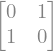

**W10' = W10 P**

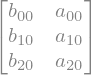

**W21' (bias unchanged, hidden weights permuted)**

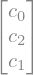

**y'(x)**

**y'(x) - y(x) simplifies to**

In [46]:
# Swap permutation matrix (2×2)
P = sp.Matrix([[0, 1],
               [1, 0]])
show("Permutation matrix P (swap hidden units)", P)

# Apply permutation to weights
W10_p = W10 * P

W21_no_bias = sp.Matrix([c1, c2])          # (2×1)
W21_no_bias_p = P.T * W21_no_bias          # reordered
W21_p = sp.Matrix([c0, W21_no_bias_p[0], W21_no_bias_p[1]])

# Forward pass with permuted weights
h1_p = W10_p.T * s0
s1_p = sp.Matrix([f(h1_p[0]), f(h1_p[1])])
s1_aug_p = sp.Matrix([1, s1_p[0], s1_p[1]])
y_p = (W21_p.T * s1_aug_p)[0]

show("W10' = W10 P", W10_p)
show("W21' (bias unchanged, hidden weights permuted)", W21_p)
show("y'(x)", y_p)

# The key check
diff_perm = sp.simplify(y_p - y)
show("y'(x) - y(x) simplifies to", diff_perm)


## 3.6.2 Sign-reversal symmetry (needs odd activation like tanh)

Now set hidden activation to $\tanh$, which is odd:
$$\tanh(-h) = -\tanh(h).$$

Flip one hidden unit (say unit 1):
- flip sign of its incoming weights: first column of $W^{10}$
- flip sign of its outgoing weight: the matching entry in $W^{21}$ (the $c_1$ slot)

Claim: output stays identical.


| Symbol                                       | Meaning (semantics)                                                                                              | Type / typical shape                    | Where it appears             |
| -------------------------------------------- | ---------------------------------------------------------------------------------------------------------------- | --------------------------------------- | ---------------------------- |
| $x$                                          | input / observation                                                                                              | vector in $\mathbb{R}^N$                | input to network             |
| $x_j$                                        | $j$-th input feature                                                                                             | scalar                                  | 3.2, 3.4, 3.5                |
| $x^{(\alpha)}$                               | training sample $\alpha$                                                                                         | vector                                  | 3.4 (dataset)                |
| $x^{(\alpha)}_j$                             | feature $j$ of sample $\alpha$                                                                                   | scalar                                  | 3.4, 3.5                     |
| $x_0=1$                                      | bias input node                                                                                                  | scalar constant                         | 3.2, 3.5 (bias trick)        |
| $y$                                          | network output (prediction)                                                                                      | scalar in these notes                   | 3.2–3.6                      |
| $y_T$                                        | target label (ground truth)                                                                                      | scalar                                  | 3.3–3.6                      |
| $y_T^{(\alpha)}$                             | target for sample $\alpha$                                                                                       | scalar                                  | 3.4                          |
| $y(x;w)$                                     | model function (MLP mapping)                                                                                     | scalar function                         | 3.2, 3.3                     |
| $v$                                          | layer index (literal)                                                                                            | integer                                 | 3.2, 3.5                     |
| $v', v''$                                    | “relative” deeper layers                                                                                         | integers                                | 3.2, 3.5                     |
| $L$                                          | output layer index                                                                                               | integer                                 | 3.2, 3.5                     |
| $j,i,k$                                      | neuron indices within a layer                                                                                    | integers                                | throughout                   |
| $\alpha$                                     | training example index                                                                                           | integer, $\alpha=1..p$                  | 3.4–3.5                      |
| $p$                                          | number of training samples                                                                                       | integer                                 | 3.4                          |
| $N$                                          | input dimension (features)                                                                                       | integer                                 | 3.3, 3.5                     |
| $N_v$                                        | #neurons in layer $v$ (often excluding bias)                                                                     | integer                                 | 3.2, 3.5, 3.6                |
| $N_1, N_2$                                   | hidden-layer widths in example                                                                                   | integers                                | 3.5.2                        |
| $s^v_j$                                      | **activity / activation** of neuron $(v,j)$ (post-nonlinearity)                                                  | scalar; stacked as vector $s^v$         | 3.2–3.5                      |
| $h^v_j$                                      | **total input / pre-activation** of neuron $(v,j)$                                                               | scalar; stacked as vector $h^v$         | 3.2–3.5                      |
| $f^v_j(\cdot)$                               | transfer / activation function of neuron $(v,j)$                                                                 | scalar→scalar                           | 3.2, 3.5                     |
| $f^v(\cdot)$                                 | layerwise activation (vectorized)                                                                                | elementwise map                         | 3.2, 3.5                     |
| $f'(h)$                                      | derivative of activation                                                                                         | scalar                                  | 3.4–3.5                      |
| $f^0(h)=h$                                   | identity activation (input)                                                                                      | —                                       | 3.2, 3.5.2                   |
| $\tanh(h)$, logistic sigmoid                 | common nonlinearities                                                                                            | —                                       | 3.2, 3.5, 3.6                |
| $w$                                          | model parameters (all weights)                                                                                   | collection / vector                     | 3.2–3.6                      |
| $w_j$                                        | weight for feature $j$ (single neuron)                                                                           | scalar                                  | 3.4                          |
| $w^{v'v}_{ij}$                               | weight from neuron $(v,j)$ to neuron $(v',i)$                                                                    | scalar edge weight                      | 3.2, 3.5                     |
| $w^{v0}_{j0}$                                | bias weight (encodes $-\theta^v_j$)                                                                              | scalar                                  | 3.2                          |
| $\theta, \theta_i$                           | threshold / bias (often absorbed into bias weight)                                                               | scalar                                  | 3.2, 3.3                     |
| $w^{v'v}_i$                                  | incoming weight **vector** into neuron $(v',i)$                                                                  | in $\mathbb{R}^{N_v+1}$ (bias included) | 3.2 (fully-connected)        |
| $W^{v'v}$                                    | weight matrix from layer $v$ to $v'$                                                                             | in $\mathbb{R}^{(N_v+1)\times N_{v'}}$  | 3.2, 3.5.2                   |
| $W^{v'v\top}$                                | transpose (used in forward equations)                                                                            | $N_{v'}\times(N_v+1)$                   | 3.2, 3.5.2                   |
| $P(v',i)$                                    | parent set: immediate inputs to neuron $(v',i)$                                                                  | set (or full vector in FC case)         | 3.2, 3.5                     |
| $C(v',i)$                                    | children set: immediate outputs fed by neuron $(v',i)$                                                           | set                                     | 3.5                          |
| $\odot$                                      | Hadamard / elementwise product                                                                                   | vector op                               | 3.5.2 backward pass          |
| $\cdot$                                      | dot product                                                                                                      | vector op                               | 3.2, 3.5                     |
| $(\cdot)^\top$                               | transpose                                                                                                        | matrix op                               | 3.2, 3.5                     |
| $E_T[w]$                                     | training error / empirical risk                                                                                  | scalar objective                        | 3.4                          |
| $e(y_T,y)$                                   | per-sample loss                                                                                                  | scalar                                  | 3.4                          |
| $\arg\min_w$                                 | minimizer operator                                                                                               | —                                       | 3.4                          |
| $w(t)$                                       | weights at iteration $t$                                                                                         | vector / set                            | 3.4                          |
| $\eta$                                       | learning rate / step size                                                                                        | scalar                                  | 3.4, 3.5                     |
| $\nabla E_T$ / “gradient”                    | vector of partial derivatives                                                                                    | same shape as $w$                       | 3.4                          |
| $\frac{\partial E_T}{\partial w^{v'v}_{ij}}$ | gradient component                                                                                               | scalar                                  | 3.4                          |
| $\delta^{v'}_i$                              | “local error” at neuron $(v',i)$, defined as $\delta^{v'}_i=\frac{\partial y}{\partial h^{v'}_i}$ in these notes | scalar                                  | 3.5                          |
| $\delta^L_1$                                 | output-layer local error                                                                                         | scalar                                  | 3.5                          |
| $\delta^v$                                   | vector of local errors in layer $v$                                                                              | in $\mathbb{R}^{N_v}$                   | 3.5.2                        |
| $\tilde h^v$ (written as $h^e$ in the text)  | $h^v$ **without bias node**                                                                                      | in $\mathbb{R}^{N_v}$                   | 3.5.2 + Table 1              |
| $\tilde w$ / $w^e$ (written as $w^e$)        | weights without bias entries                                                                                     | vector/matrix                           | 3.5.2 (notes “without bias”) |
| $W^{f21}$                                    | $W^{21}$ without bias entries (columns)                                                                          | in $\mathbb{R}^{N_1\times N_2}$         | 3.5.2 + Table 1              |
| $M$                                          | hidden width in universal approximation theorem                                                                  | integer                                 | 3.3                          |
| $K$                                          | compact interval/domain                                                                                          | set                                     | 3.3                          |
| $\varepsilon$                                | approximation tolerance                                                                                          | scalar $>0$                             | 3.3                          |
| $\max_{x\in K}$                              | uniform / sup error criterion                                                                                    | —                                       | 3.3                          |
| $\epsilon$                                   | small finite-difference step                                                                                     | scalar $\ll1$                           | 3.5.3.1                      |
| $O(\epsilon^2)$                              | truncation error term                                                                                            | asymptotic order                        | 3.5.3.1                      |
| $O(n)$, $O(n^2)$                             | complexity (weights count $n$)                                                                                   | asymptotics                             | 3.5.3.1                      |
| $n$                                          | total number of weights                                                                                          | integer                                 | 3.5.3.1                      |
| $\pi$                                        | permutation of hidden indices                                                                                    | mapping                                 | 3.6                          |
| $\Pi(i)$                                     | permuted index (notation in notes)                                                                               | integer                                 | 3.6                          |
| $w'$                                         | symmetric/alternative parameter set                                                                              | weights                                 | 3.6                          |
| $N_v!$                                       | permutations per hidden layer                                                                                    | integer count                           | 3.6.1                        |
| $2^{N_v}$                                    | sign-reversal combos per hidden layer                                                                            | integer count                           | 3.6.2                        |
| $\prod_{v=1}^L N_v!2^{N_v}$                  | total equivalent solutions factor                                                                                | integer count                           | 3.6                          |
